# CS 503 Foundation Models: Part 2 - nanoMaskGIT

#### Goals:

The goal of this second part is to familiarize yourself with the following topics:
- Bi-directional attention
- Encoder-only Transformer (e.g. BERT, MaskGIT, ...) models
- Basic masking schemes
- Masked modelling on text and images
- Masked inference

This notebook should give you a solid foundation of working with masked image models.
If you want to know more about these topics, please see some of the reading material in the lectures and at the bottom of this notebook, and feel free to ask the TAs.


#### Instructions:

- Your task is to fill in the missing code in the acompagning codebase (highlighted by `???`), run the training loops and evaluate the trained models with this notebook.
- Submit the notebook with all cells executed, as well as `nanofm/models/maskgit.py`.
- The notebooks are individual homework.

# 1. Setup

Please follow the instructions in the [README.md](../README.md) file to set up the environment.

### 1.1 Imports

In [1]:
# Switch path to root of project
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
current_folder = globals()['_dh'][0]
os.chdir(os.path.dirname(os.path.abspath(current_folder)))

%load_ext autoreload
%autoreload 2

In [2]:
import re
import torch
from einops import rearrange
from transformers import AutoTokenizer
from tokenizers.processors import TemplateProcessing

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

from nanofm.utils.checkpoint import load_model_from_safetensors
from nanofm.data.vision.tokenized_mnist import create_tokenized_mnist_dataloader, detokenize_MNIST

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# The flag below controls whether to allow TF32 on matmul. This flag defaults to False in PyTorch 1.12 and later.
torch.backends.cuda.matmul.allow_tf32 = True
# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
torch.backends.cudnn.allow_tf32 = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_grad_enabled(False)

/scratch/michal/EPFL-VI-Spring-CS503/2026-Spring-CS503-Visual-Intelligence-Homework/NanoFM_Homeworks/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.autograd.grad_mode.set_grad_enabled(mode=False)

---

## 2 Training nanoMaskGIT on MNIST for image generation

In this exercise, we will implement a simplified masked generative model, similar to [MaskGIT](https://masked-generative-image-transformer.github.io/). 
As with our nanoGPT implementation, we will train it on MNIST for image generation, but will also later explore using it for text generation on TinyStories!

#### Masked modeling - Training objective

In contrast to autoregressive models that are trained to predict the next token given the context so far, masked generative models like MaskGIT are trained to predict any (masked-out) token given any other (non-masked) subset of tokens.
Consider the following example: 

**Original Sentence:**  
```
"The quick brown fox jumps over the lazy dog."
```

**Masked Training Example (cloze):**  
```
"The quick [MASK] fox jumps over the [MASK] dog."
```

**Goal:**  
The model must predict:
- `[MASK]` → "brown"
- `[MASK]` → "lazy"

By repeatedly training the model to predict these randomly masked tokens across a large dataset, MaskGIT learns how tokens fit contextually within sequences.


#### Masked modeling - Inference


By training a model with randomized masking ratios, we are able to use it to progressively "unmask" a fully masked initial sequence.
At inference, the model starts with all tokens masked and progressively unmasks tokens in multiple steps. Let's show an inference example generating two (`k=2`) tokens at a time.

**Initial Masked Sequence:**  
```
"[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]"
```

**Step-by-step Generation (k=2 tokens at a time):**  

- **Step 1:**  
```
"The [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] dog."
```

- **Step 2:** (unmask next 2 most confident tokens)  
```
"The quick [MASK] [MASK] [MASK] [MASK] [MASK] lazy dog."
```

- **Step 3:** (unmask next 2 tokens)  
```
"The quick [MASK] fox [MASK] [MASK] [MASK] lazy dog."
```

- **Step 4:** (unmask next 2 tokens)  
```
"The quick brown fox jumps [MASK] the lazy dog."
```

- **Step 5 (Final):** (all tokens unmasked)  
```
"The quick brown fox jumps over the lazy dog."
```

At each inference step, MaskGIT predicts all masked-out tokens simultaneously (in parallel), and, based on the predicted probabilites, selects the `k` (here `k=2`) most likely tokens. 
After deciding on which tokens to use, we sample a token index from the predicted probability distribution for each token, and add the tokens to the sequence. 
This, now slightly less masked, sequence is then used as the input for the next round, where again, the `k=2` most confident tokens are chosen of the remaining masked targets.

A crucial difference of masked models to next-token prediction is that at each inference step we can freely choose the number of tokens `k` to simultaneously decode. 
Depending on the choice of `k`, this can speed up inference significantly, at little cost to generation performance. 
For example, see the comparison between raster-scan autoregressive, and masked generation below.
Each frame of the gif is one generation step. Autoregressive generation predicts each token one-by-one, while masked models may predict them in parallel.

![adsf](https://masked-generative-image-transformer.github.io/imgs/sampling.gif)

### 2.1 Overview and tasks

To implement nanoMaskGIT, we ask you to complete the subsections below by directly filling in the missing lines in the code base.

#### 2.1.1 Initialize nanoMaskGIT (5 points)

We will reuse the exact same Transformer layers and trunk built last week for the nanoGPT model, but this time we will use it to assemble a MaskGIT-like model in `nanofm.models.maskgit.MaskGIT`.
It consists of a few operations executed in series. Initialize the following modules in the constructor:
1. The discrete input tokens are embedded with an `nn.Embedding` layer. Initialize `self.input_embedding` accordingly, taking into account the vocabulary size.
2. On top of that, we add learnable positional embeddings. Initialize `self.positional_embedding` as an `nn.Parameter` containing a randomly initialized Tensor of shape (`max_seq_len`, `dim`).
3. To indicate masked-out tokens and provide placeholders to write the targets, initialize `self.mask_token` as an `nn.Parameter` containing a randomly initialized Tensor of shape (`dim`).
4. This then gets passed to a Transformer trunk. Initialize `self.trunk` with the trunk you implemented last week.
5. Finally we project the trunk output through a LayerNorm and output projection that maps the elements from the Transformer dimension to the vocabulary size (as a one-hot vector per token). Initialize `self.out_norm` and `self.to_logits`. The bias term for `self.to_logits` should always be set to False.

#### 2.1.2 Implement the forward function and loss (10 points)

Next, let's implement the `forward_model` function:
1. Pass the input tokens through the embedding. 
2. Given the `mask`, replace these embeddings by the learned `self.mask_token`, wherever `mask == True`.
3. Add the positional embedding, pass it through the Transformer trunk, output normalization, and output projection.
4. When calling the Transformer trunk, no attention mask needs to be specified. This model performs full self-attention between all masked and non-masked tokens.

Finally, we need to compute the cross-entropy loss between the logits and the ground-truth targets. Please complete the `compute_ce_loss` function accordingly, and take into account the ignore_index token. We do not want to compute a loss on non-masked tokens that we pass as input; we only compute it on masked-out tokens that we predict.

#### 2.1.3 Implement random masking (15 points)

As used in the `forward` function, during training we want to randomize the `mask` you just applied to the inputs. 
For that, please complete the `generate_random_mask` function that should return a random mask where True = masked-out and False = not masked.
Each sample in the batch should randomly mask out between 1 and L tokens, where L is the sequence length. 
When L tokens are masked-out, it means there is no input and all tokens are predicted.
When only 1 token is masked-out, it means that all but one token are given as input, and only one is predicted. 
You should be able to see why we have to have at least one token masked.

The returned mask tensor should be of type `torch.BoolTensor`, moved to the same device (GPU) as `seq`, and be of shape (B, L).
Note that both the number of mask tokens, as well as the placement of the masks should be sampled completely uniformly at random, for every sample in the batch individually.
That means you should not apply and broadcast the same mask to the entire batch.

#### 2.1.4 MaskGIT schedule and generation function (20 points)

Now let's implement the generation function. We do that in two steps:

First, let's implement a so-called generation schedule in `get_maskgit_schedule`. 
Its task is to give us a list of number of tokens to unmask at every prediction step. 
It's quite common to make this a cosine schedule, i.e. where the tokens are unmasked slowly at the beginning, then in the middle many tokens are predicted at once, and finally in the end we ramp down again.
Here we will implement a much simpler constant schedule, where the number of unmasked tokens per step is constant.
For example, if total_tokens = 17 and num_steps = 8, then the schedule should be: [2, 2, 2, 2, 2, 2, 2, 3]. 
If the total number of tokens is not divisible by the number of steps, we simply add the remainder to the last step.
The `schedule` should be a list of integers of length `num_steps`, where each integer represents the number of tokens to unmask at that step. 
The sum of the integers in `schedule` should equal `total_tokens`.

With the simple schedule implemented, let's use it in the `generate` function. Generation is performed in a loop in the following steps:
1. Given the sequence and mask so far, simply pass them through the network to get the logits.
2. Then, select the subset of logits that we actually want to predict, i.e. the masked-out tokens.
3. Over all these predicted tokens, we only want to keep the most "confident" predictions. We select for these by computing the maximum logit value for each token as a proxy. The higher the maximum logit is for a given token, the more "confident" it is in its prediction.
4. Now, let's select the top-k tokens according to these confidence scores. You get the number of tokens `k` from the generation schedule.
5. Sample the token indices from these `k` selected token logits. You should use the `sample_tokens` function from `utils/sampling.py`, and remember to pass the relevant sampling hyperparameters.
6. Update the sequence and mask for the next round using the newly sampled tokens and their positions.
7. Repeat until the end of the generation schedule, when the sequence is fully unmasked.

### 2.2 Training the model

We defined a training config for you in: `cfgs/nanoMaskGIT/mnist_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 1xV100 node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=1 run_training.py --config cfgs/nanoMaskGIT/mnist_d8w512.yaml
```

This training should be pretty fast and only take a few minutes. Because masked image models are harder to overfit, we increased the number of training steps five-fold, compared to nanoGPT. You should reach a final validation loss below 0.57, and your loss curves should look something like the following:

<img src="./assets/nanoMaskGIT_mnist.png" alt="nanoMaskGIT MNIST loss curves" width="1000">

### 2.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).

<img src="./assets/nanoMaskGIT-mnist.jpg" alt="nanoMaskGIT MNIST loss curves" width="1000">

### 2.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [3]:
ckpt_path = './outputs/nanoMaskGIT/mnist_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.174528M parameters


Let's plot some class-conditional generations! We seed the generation by providing the first token, whose index is equal to the number we'd like to generate.
For that token, we initialize the mask with `False`, i.e. indicating that that token is given as input, i.e. not masked. 
The rest of the tokens are masked, and it does not matter what value they have in the `seq` tensor, as they are overwritten by the learnable mask token in the Transformer.

In [4]:
label = 5

seq = torch.zeros(50, dtype=torch.long, device=device)
mask = torch.ones(50, dtype=torch.bool, device=device)
seq[0] = label
mask[0] = False

output = model.generate(seq, mask, num_steps=8, temp=1.0, top_p=0.9, return_history=False)
output

tensor([[ 5, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
         18, 10, 10, 10, 10, 10, 10, 22, 12, 10, 10, 10, 10, 10, 10, 14, 10, 10,
         10, 10, 10, 14, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10]],
       device='cuda:0')

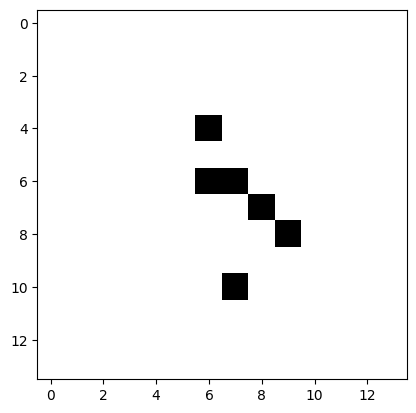

In [5]:
reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
plt.imshow(reconst[0], cmap='gray_r')

<img src="./assets/maskgit_2.4_example_output1.png" alt="nanoMaskGIT example output 1" width="500">

Let's now generate 10 random samples for all 10 classes. Most should look quite reasonable.

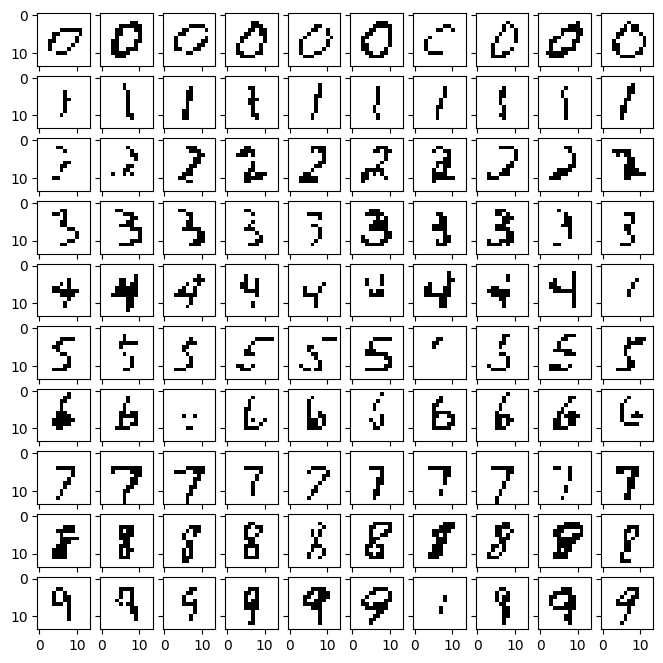

In [6]:
def generate_samples(model, num_steps=8, temp=1.0, top_p=0.0, top_k=0.0, n_samples=10):
    fig = plt.figure(figsize=(8., 8.))
    grid = ImageGrid(fig, 111, nrows_ncols=(10, n_samples), axes_pad=0.1)
    for label in range(10):
        for sample_idx in range(n_samples):
            grid_idx = label * n_samples + sample_idx
            
            seq = torch.zeros(50, dtype=torch.long, device=device)
            mask = torch.ones(50, dtype=torch.bool, device=device)
            seq[0] = label
            mask[0] = False
            output = model.generate(seq, mask, num_steps=num_steps, temp=temp, top_p=top_p, top_k=top_k, return_history=False)
            
            reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
            grid[grid_idx].imshow(reconst[0], cmap='Greys', vmin=0, vmax=1)
    plt.show()
    
generate_samples(model, num_steps=8, temp=0.7, top_p=0.9, top_k=0.0)

<img src="./assets/maskgit_2.4_example_output2.png" alt="nanoMaskGIT example output 1" width="1000">

### 2.5 Open-ended questions (10 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

#### 2.5.1 Intermediate generation steps

`model.generate` has an optional flag `return_history`. Show the intermediate generation steps. What do you observe?

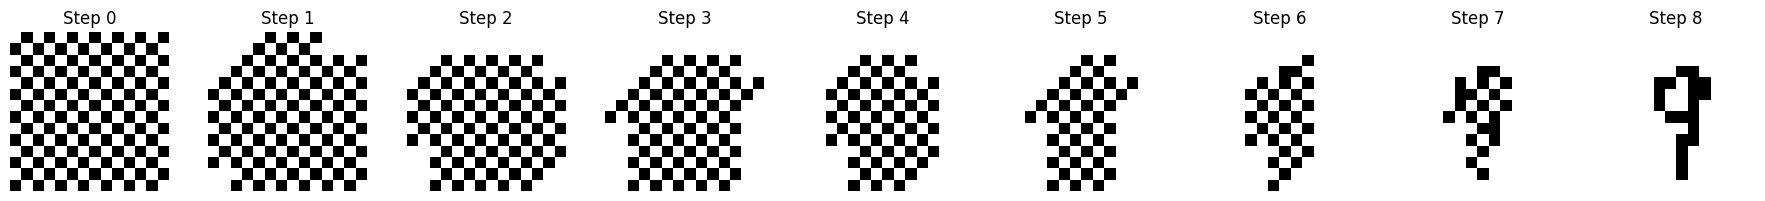

In [8]:
# Fill your answer here
label = 9
seq = torch.zeros(50, dtype=torch.long, device=device)
mask = torch.ones(50, dtype=torch.bool, device=device)
seq[0] = label
mask[0] = False

seq_history, mask_history = model.generate(seq, mask, num_steps=8, temp=0.7, top_p=0.9, return_history=True)

fig, axes = plt.subplots(1, len(seq_history), figsize=(2 * len(seq_history), 2))
for i, (s, m) in enumerate(zip(seq_history, mask_history)):
    reconst = detokenize_MNIST(s.unsqueeze(0).to(device) if s.dim() == 1 else s, patch_size=2, account_for_labels=True).cpu()
    axes[i].imshow(reconst[0], cmap='gray_r')
    axes[i].set_title(f'Step {i}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

When looking at the intermediate steps, the model first tends to fill in the easiest and most confident parts this dataser, ie MNIST that is the background. Early on image looks kind of noisy, and at the end of generation the digit becomes visible, and the latest steps refine the ambiguous parts. So the model is clearly not generating everything equally

#### 2.5.2 Number of inference steps

With MaskGIT, we can freely choose the number of inference steps `k`. We default to `k=8`, but how does generation with `k` = 1, 4, 8, 16, 32, 49 perform? What do you observe?

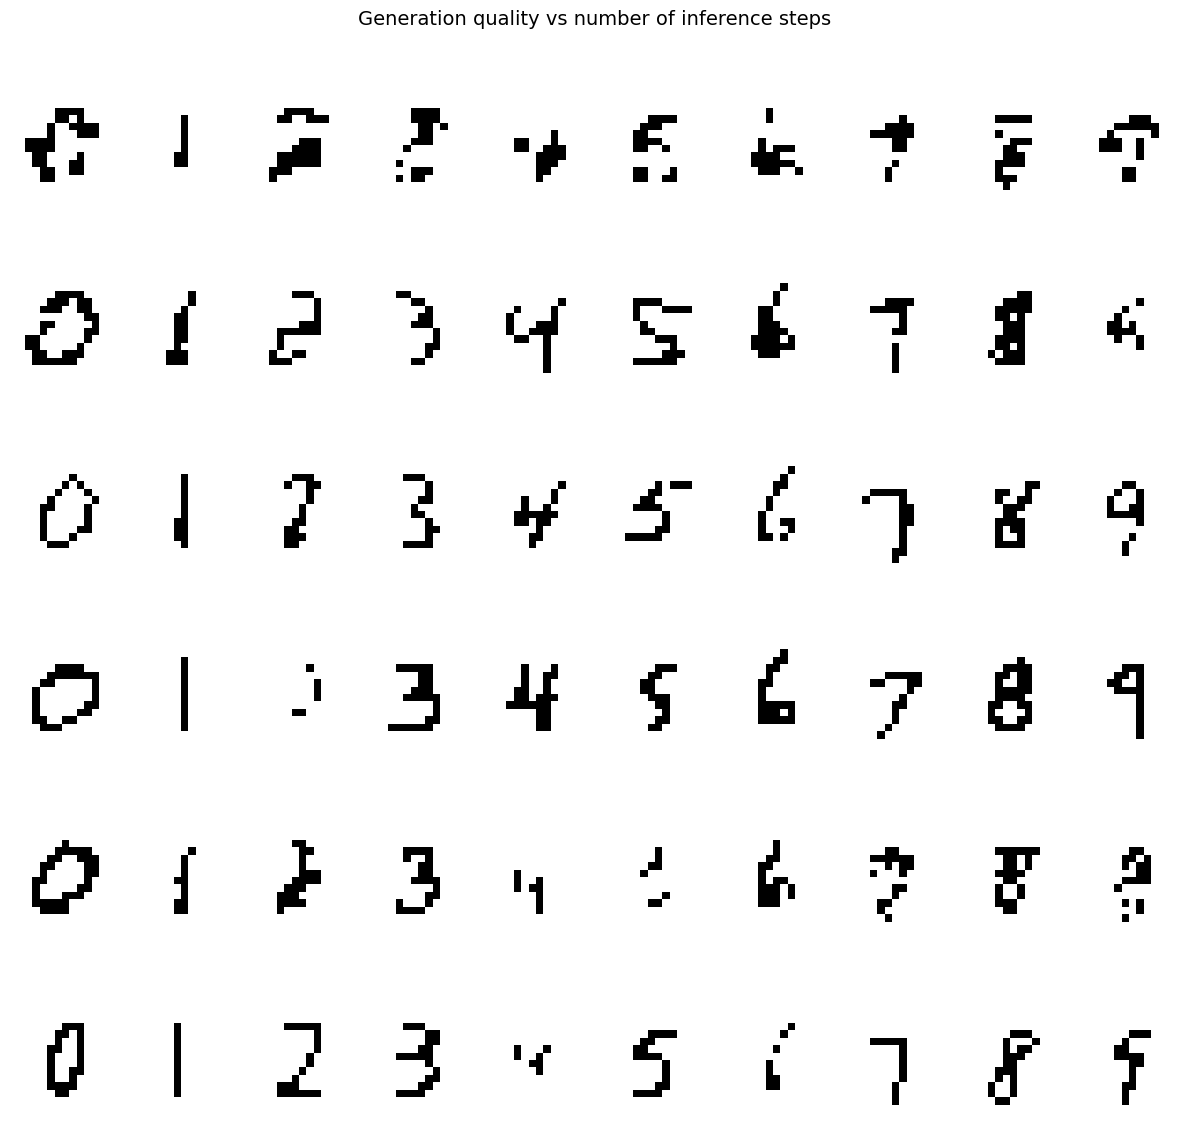

In [15]:
# Fill your answer here
k_values = [1, 4, 8, 16, 32, 49]
fig, axes = plt.subplots(len(k_values), 10, figsize=(12, 2 * len(k_values)))
for row, k in enumerate(k_values):
    for col in range(10):
        seq = torch.zeros(50, dtype=torch.long, device=device)
        mask = torch.ones(50, dtype=torch.bool, device=device)
        seq[0] = col  # class label
        mask[0] = False
        output = model.generate(seq, mask, num_steps=k, temp=0.7, top_p=0.9, return_history=False)
        reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
        axes[row, col].imshow(reconst[0], cmap='Greys', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'k={k}', fontsize=12, rotation=0, labelpad=30)
plt.suptitle('Generation quality vs number of inference steps', fontsize=14)
plt.tight_layout()
plt.show()

If we use very few steps, the quality is worse, because the model has to predict too many tokens at once without enough context. If we use more steps, the quality improves, since each round can condition on more already decoded tokens.
From my observations very small numbers of steps gave noisier or less recognizable digits, while increasing the number of steps made the digits cleaner and more stable. I expect the gain to become smaller after we hit a certian number of steps. I noticed a huge jump in perfomrance from 4-8.

---

## 3 Training nanoGPT on TinyStories

Masked generation is quite common for image generation, but has seen a recent resurgence for language models too (e.g. see [LLaDA](https://ml-gsai.github.io/LLaDA-demo/)). 
Let's run a little experiment and train a masked model on TinyStories, just as we did with nanoGPT.

### 3.1 Loading the tokenizer and helper functions

In [16]:
# Load the GPT-2 tokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2", trust_remote_code=True)

# Add padding, start-of-sequence, and end-of-sequence tokens
tokenizer.add_special_tokens({'pad_token': '[PAD]'})
tokenizer.add_special_tokens({
    'bos_token': '[SOS]',
    'eos_token': '[EOS]',
})
tokenizer._tokenizer.post_processor = TemplateProcessing(
    single="[SOS] $A [EOS]",
    special_tokens=[('[EOS]', tokenizer.eos_token_id), ('[SOS]', tokenizer.bos_token_id)],
)
tokenizer

GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[SOS]', 'eos_token': '[EOS]', 'unk_token': '<|endoftext|>', 'pad_token': '[PAD]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50257: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50258: AddedToken("[SOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50259: AddedToken("[EOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [17]:
def token_ids_to_text(token_ids, text_tokenizer):
    """ Helper function to turn token sequences back to well-formatted text. """
    decoded = text_tokenizer.decode(token_ids)
    # Remove [SOS], [EOS], and [PAD] tokens along with surrounding horizontal whitespace only.
    decoded = re.sub(r'[ \t]*\[(SOS|EOS|PAD)\][ \t]*', ' ', decoded)
    # Collapse extra horizontal spaces in each line without touching newline characters.
    decoded = '\n'.join([re.sub(r'[ \t]+', ' ', line).strip() for line in decoded.splitlines()])
    return decoded

### 3.2 Training the model

We defined a training config for you in: `cfgs/nanoMaskGIT/tinystories_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 2xV100 node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 run_training.py --config cfgs/nanoMaskGIT/tinystories_d8w512.yaml
```

This training should take over one hour. You should reach a final validation loss around 2.05, and your loss curves should look something like the following:

<img src="./assets/nanoMaskGIT_tinystories.png" alt="nanoMaskGIT TinyStories loss curves" width="1000">

### 3.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).

[Note] Your screenshot must clearly show your Weights & Biases (W&B) account (username/entity), usually visible in the top-right corner of the page.

<img src="./assets/nanoMaskGIT-tinystories.jpg" alt="nanoMaskGIT TinyStories loss curves" width="1000">

### 3.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [18]:
ckpt_path = './outputs/nanoMaskGIT/tinystories_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.174528M parameters


Let's generate some random (unconditional) stories!

In [19]:
for _ in range(5):
    seq = torch.zeros(256, dtype=torch.long, device=device)
    mask = torch.ones(256, dtype=torch.bool, device=device)
    output = model.generate(seq, mask, num_steps=128, temp=1.0, top_k=100, return_history=False)
    print(token_ids_to_text(output[0], text_tokenizer=tokenizer))
    print('\n' + '-'*50 + '\n')

Oncemy had to be successful. They made a very special friend and cheered.

--------------------------------------------------

Once upon a time, was a little girl called Sarah. She was only years old and had to design. She. It was a boring idea, but this knew something she wanted to do.


She began to put out the things she could do make. So she collected some different, stones and and markers. She quickly made them look and designs different. After lots of hard, Sarah walls were all amazing and everything.

One day, Sarah had a lot better project. She designed to design things with of different and colours andons. And she gathered proud of the work on their project.

When she was done of her project she was very but proud of her. She was so pleased! her picture were so of colour work, Sarah had happy it and the knew she she was something really.


The end.

--------------------------------------------------

Once upon a time, there was a little boy. The mouse.

-----------------------

<img src="./assets/maskgit_3.4_example_output.png" alt="nanoMaskGIT example output for 3.4" width="1000">

### 3.5 Open-ended questions (10 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

#### 3.5.1 Intermediate generation steps

Similar as in 2.5.1, `model.generate` has an optional flag `return_history`. Show the intermediate generation steps. What do you observe?

In [25]:
# Fill your answer here
# 3.5.1 — Intermediate steps for text
seq = torch.zeros(256, dtype=torch.long, device=device)
mask = torch.ones(256, dtype=torch.bool, device=device)
seq_history, mask_history = model.generate(seq, mask, num_steps=16, temp=1.0, top_k=100, return_history=True)

for i in range(0, len(seq_history), 4):  
    text = token_ids_to_text(seq_history[i], text_tokenizer=tokenizer)
    num_masked = mask_history[i].sum().item()
    print(f"--- Step {i} ({int(num_masked)} tokens still masked) ---")
    print(text[:200])
    print()

--- Step 0 (256 tokens still masked) ---
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

--- Step 4 (192 tokens still masked) ---
Mary day a time, was called playing with the rag. She was having fun, a rag liked could play her day. Mary up and old other
tried!!! and started could time!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

--- Step 8 (128 tokens still masked) ---
Mary day a time, was called playing with the rag. She was having fun, a rag liked could play her day. Mary up and old other
tried to come gentle and started could time. But Mary her. said
Mary play it

--- Step 12 (64 tokens still masked) ---
Mary day a time, was called playing with the rag. She was having fun, a rag liked could play her day. Mary up and old other
tried to come gentle and started could time. But Mary her. said
Mary play it

--- Step 16 (0 tokens still 

I rerun the command many times so the example I talk about, is not the one visible above, but the point still stands.

The intermediate steps show that the model gradually builds the text by filling in more and more masked positions, but the process looks much less natural than in image generation. At the beginning, when everything is masked, the output is just meaningless placeholder tokens. After a few steps, some common words and bits of sentence structure appear, so the model starts forming something that vaguely looks like a story. For example, phrases like "Once ...was..there was" appear early, which suggests the model first fills in very common, high-confidence story patterns.

But even after more and more tokens are unmasked, the text is still not really coherent. It keeps looking like locally plausible fragments rather than a proper sentence or story. In my example, even the final output is still very broken, with phrases like “Once day was time” or “the girl were Jack by”. So the model clearly learns some shallow structure of tinystories, but it struggles with grammar and global coherence.
Overall, the intermediate steps suggest that MaskGIT can quickly recover the general style or template of the text, but not the actual logical and grammatical flow nearly as well as an autoregressive model.

#### 3.5.2 Number of inference steps

Similar as in 2.5.1, with MaskGIT, we can freely choose the number of inference steps `k`. We default to `k=128`, but how does generation with `k` = 1, 16, 32, 64, 128, 256 perform? What do you observe?

In [21]:
# Fill your answer here
# 3.5.2 — Varying k for text
k_values = [1, 16, 32, 64, 128, 256]
for k in k_values:
    seq = torch.zeros(256, dtype=torch.long, device=device)
    mask = torch.ones(256, dtype=torch.bool, device=device)
    output = model.generate(seq, mask, num_steps=k, temp=1.0, top_k=100, return_history=False)
    print(f"=== k={k} ===")
    print(token_ids_to_text(output[0], text_tokenizer=tokenizer)[:300])
    print('\n' + '-'*50 + '\n')

=== k=1 ===
J upon was time there there a forest friends. named Tim old to day. One a that ofmy would day mom the that and. a

park to saw to, said the them her was said the. a bird She. saw to., of scared so. She!. to the, he the help

girl and!"
the
" excited the to looked It not the too looked. Tim to
. " we

--------------------------------------------------

=== k=16 ===
Tom upon a time,. was a three year old.year. was and up with. big. One a very en. appeared play of an do was tomy. the to

daymy on it when her Tommy was She with
too
had something to.. that year, decided was time surprise idea. new He with his, " would think fun said Tommy.. I hadSo, to be game to 

--------------------------------------------------

=== k=32 ===
Once upon a a,, the a big named. to .

--------------------------------------------------

=== k=64 ===
Once there a time there was a machine. to The man cheered.

--------------------------------------------------

=== k=128 ===
Oncemy was on a holiday.

With k=1, the model predicts everything in one go, and the result is very messy. It produces many real words and maybe some tinystories like phrases, but the text is very incoherent and grammatically broken. With k=16, it sometimes looks a bit more story-like, but it is still mostly nonsense with a lot of repetition and bad grammar.
For larger values like 32, 64, 128, 256, the outputs often become shorter and more collapsed rather than clearly better. So in my experiments, more steps did not reliably improve the generations. The outputs changed, but they were still bad in different ways: sometimes too noisy, sometimes too short, sometimes repetitive.


#### 3.5.3 Comparison to autoregressive generation

How would you compare these results to the ones you got from nanoGPT? What are some failure modes you observe? And what could be some benefits? Do you have any thoughs on how we can improve text generation with masked models, or should we just stick to autoregressive models?

In [27]:
# Fill your answer here


Compared to nanogpt, the maskgit text generations are clearly worse. nanogpt produces text that is much more coherent, more grammatical, and overall feels much more like an actual story. Even when nanogpt makes mistakes, it usually keeps some reasonable left to right flow. maskgit, on the other hand, often gives text that feels like it knows the general tinystories vibe, but not really how to write a proper consistent sentence or narrative.
The main failure modes I observed are broken grammar, repetition, strange local phrases that do not fit together globally, and partial collapse into very short or generic outputs. sometimes the model produces many plausible words, but they feel more like fragments pasted together than a real story. so it seems to capture local statistics and common patterns like “once upon a time”, but it struggles much more with global coherence and sequential structure.
I think this makes sense. with maskgit, the model predicts many positions in parallel, which is attractive computationally, but for language this seems much harder, because word order and long range consistency matter a lot. text is just much more naturally sequential than MNIST digits.
That said, masked models do have some real benefits. generation can in principle be much faster, since we do not need one forward pass per token. they are also much more natural for infilling or editing, because they can fill holes anywhere in the sequence rather than only continue from the end. and since each prediction can use both left and right context, they may also be useful in settings where bidirectional context really matters.
As for improving masked text generation, I do not think we should just immediately give up and always use autoregressive models, but in this setup autoregressive is clearly better. obvious things to try would be larger models, more training data, better masking schedules, and maybe a less naive generation schedule.
one idea that might also help is to make training look more like inference. right now, the intermediate states during generation are not really clean text, they are partially decoded sequences containing model mistakes. so maybe it makes sense during training to corrupt not only the masked positions, but also some of the visible tokens, and train the model to recover the original clean sequence. for example, instead of showing it only correct visible context, we could give it slightly corrupted visible text like “he say” or “I tells” and ask it to predict the clean version while also filling the masked holes. then the model would not only learn to fill in missing tokens, but also to correct imperfect context, which is closer to what happens during iterative generation. this would make the objective more like denoising, and it might help because the model would be trained on the kind of broken intermediate states it actually sees at inference time.
So overall, my conclusion is that for plain text generation, autoregressive models still seem like the better choice, at least here. masked models are interesting and have some real advantages, but in this experiment they are much worse at producing coherent language.

## 4 Further reading

Here is some further reading material should you want to dive deeper on masked modeling.

Masked image generation:
- [MaskGIT: Masked Generative Image Transformer](https://arxiv.org/abs/2202.04200)
- [Muse: Text-To-Image Generation via Masked Generative Transformers](https://arxiv.org/abs/2301.00704)
- [MAGE: MAsked Generative Encoder to Unify Representation Learning and Image Synthesis](https://arxiv.org/abs/2211.09117)
- [Randomized Autoregressive Visual Generation](https://arxiv.org/abs/2411.00776)
- [RandAR: Decoder-only Autoregressive Visual Generation in Random Orders](https://arxiv.org/abs/2412.01827)
- [Autoregressive Image Generation without Vector Quantization](https://arxiv.org/abs/2406.11838)
- [4M: Massively Multimodal Masked Modeling](https://arxiv.org/abs/2312.06647)

Masked text generation:
- [Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer](https://arxiv.org/abs/1910.10683)
- [Structured Denoising Diffusion Models in Discrete State-Spaces](https://arxiv.org/abs/2107.03006)
- [Large Language Diffusion Models](https://arxiv.org/abs/2502.09992)

Masked pre-training:
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805)
- [RoBERTa: A Robustly Optimized BERT Pretraining Approach](https://arxiv.org/abs/1907.11692)
- [ELECTRA: Pre-training Text Encoders as Discriminators Rather Than Generators](https://arxiv.org/abs/2003.10555)
- [Masked Autoencoders Are Scalable Vision Learners](https://arxiv.org/abs/2111.06377)
- [BEiT: BERT Pre-Training of Image Transformers](https://arxiv.org/abs/2106.08254)
- [BEiT v2: Masked Image Modeling with Vector-Quantized Visual Tokenizers](https://arxiv.org/abs/2208.06366)